In [1]:
import numpy as np
import optuna
SEED = 42

import random
import tensorflow as tf

import os
def init_seed(s):
    seed = s
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINSTIC_OPS"] = "1"
    os.environ["TF_CUDNN_DETERMINSTIC"] = "1"
    np.random.seed(seed)
    tf.config.experimental.enable_op_determinism()
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

c:\Users\natha\Documents\Git\5th-year-polytech\deep_learning\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train, X_val, X_test = np.random.uniform(0, 1, (1000, 1)), np.random.uniform(0, 1, (200, 1)), np.random.uniform(0, 1, (1000, 1))
y_train, y_val, y_test = np.sin(2*np.pi*X_train), np.sin(2*np.pi*X_val), np.sin(2*np.pi*X_test)
y_train2 = np.where((X_train > 0.5) | (X_train <= -0.5), 0.0, 1.0).astype(np.float32)
y_val2 = np.where((X_val > 0.5) | (X_val <= -0.5), 0.0, 1.0).astype(np.float32)
y_test2 = np.where((X_test > 0.5) | (X_test <= -0.5), 0.0, 1.0).astype(np.float32)
s_train, s_val, s_test = np.ones(shape=y_train.shape), np.ones(shape=y_val.shape), np.ones(shape=y_test.shape)

In [3]:
from keras import layers, Model, Input, activations, losses, metrics
from keras.optimizers import Adam

In [4]:
init_seed(2025)

In [5]:
n_unit1 = 32
n_unit2 = 64
n_unit3 = 128
learning_rate = 10**-3
activation = activations.relu

input1 = Input(shape=(1, ))
x1 = layers.Dense(n_unit1, activation=activation)(input1)
x2 = layers.Dense(n_unit2, activation=activation)(x1)
x3 = layers.Dense(n_unit3, activation=activation)(x2)
output1 = layers.Dense(1)(x3)

model1 = Model(input1, output1)

input2 = Input(shape=(1, ))
x4 = layers.Dense(10, activation=activations.relu)(input2)
x5 = layers.Dense(10, activation=activations.relu)(input2)
output2 = layers.Dense(1, activation=activations.sigmoid)(x5)

model2 = Model(input2, output2)

x = Input(shape = (1, ))

y = model1(x)
s = model2(y)
model = Model(x, outputs = [y, s])

In [6]:
model2.compile(optimizer=Adam(), loss=losses.binary_crossentropy, metrics = [metrics.BinaryAccuracy])
model2.fit(x = X_train, y = y_train2, epochs = 128, validation_data=(X_val, y_val2), batch_size=128)

Epoch 1/128
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - binary_accuracy: 0.5340 - loss: 0.6057 - val_binary_accuracy: 0.5050 - val_loss: 0.6104
Epoch 2/128
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.5620 - loss: 0.5996 - val_binary_accuracy: 0.5450 - val_loss: 0.6039
Epoch 3/128
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.5890 - loss: 0.5935 - val_binary_accuracy: 0.5850 - val_loss: 0.5974
Epoch 4/128
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.6050 - loss: 0.5877 - val_binary_accuracy: 0.6100 - val_loss: 0.5911
Epoch 5/128
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.6300 - loss: 0.5820 - val_binary_accuracy: 0.6250 - val_loss: 0.5850
Epoch 6/128
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.6540 - loss: 0.5764 - val_binary_accuracy: 0.6550 - val_loss: 0.5791
Epoch 7/128
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.6710 - loss: 0.5709 - val_binary_accuracy: 0.6750 - val_loss: 0.5734
Epoch 8/128
8/8 ━━━━━━━━━━

In [7]:
model2.trainable = False
model.compile(optimizer=Adam(), loss=[losses.mean_squared_error, losses.mean_squared_error])
model2.fit(x = X_train, y = [y_train, s_train], epochs = 128, validation_data=(X_val, [y_val, s_val]), batch_size=128)

Epoch 1/128


ValueError: y_true and y_pred have different structures.
y_true: ('*', '*')
y_pred: *


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


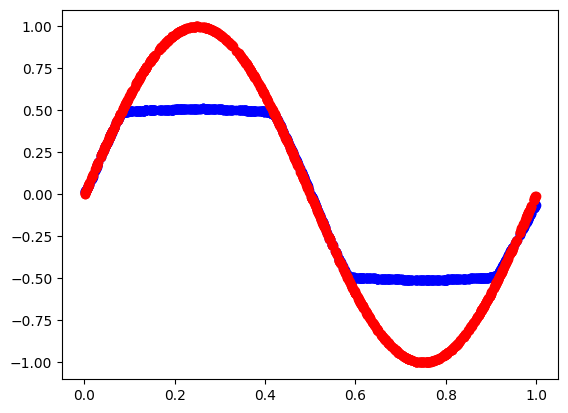

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x = X_test, y = y_pred, color = "blue")
plt.scatter(x = X_test, y = y_test, color = "red")